### Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

data_frame = pd.read_csv("C:/Users/tumik/Documents/semester 5/machine learning/project1_repo/MachineLearningRepo/Project1/data/all_fights.csv")


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]

# ============

# getting all features with diff 
diff_features_df = data_frame.filter(regex=r'_diff')

#TODO: Other attributes than diff that we will keep
# red_winner, gender, weight_class, red_stance, blue_stance, red_age, blue_age
extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", "blue_age", "fight_date"
]
extra_features_df = data_frame[extra_features]

feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)

#NOTE: maybe no buckets
# adding age buckets
bins = [17, 23, 27, 33, float("inf")]
labels = ["18-23", "24-27", "28-33", "34+"]

feature_selected_df["red_age_bucket"] = pd.cut(
    data_frame["red_age"],
    bins=bins,
    labels=labels
)

feature_selected_df["blue_age_bucket"] = pd.cut(
    data_frame["blue_age"],
    bins=bins,
    labels=labels
)


# drop red_ and blue_age
feature_selected_df = feature_selected_df.drop(columns=['red_age'])
feature_selected_df = feature_selected_df.drop(columns=['blue_age'])
# drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=['odds_diff'])


#NOTE: class variable??
class_df = data_frame[["red_winner","fight_date"]]


#NOTE: split the data based on fight date
DATE = "2023-06-01"
SPLIT_DATE = r"2023-06-01"

# splitting the data thing
x_training_df = feature_selected_df.loc[feature_selected_df['fight_date'] <= SPLIT_DATE]
x_test_df  = feature_selected_df.loc[feature_selected_df['fight_date'] > SPLIT_DATE]

# drop fight_date
x_training_df = x_training_df.drop(columns=['fight_date'])
x_test_df = x_test_df.drop(columns=['fight_date'])

# splitting the class thing
y_training_df = class_df.loc[class_df['fight_date'] <= SPLIT_DATE]
y_test_df  = class_df.loc[class_df['fight_date'] > SPLIT_DATE]

# drop fight_date
y_training_df = y_training_df.drop(columns=['fight_date'])
y_test_df = y_test_df.drop(columns=['fight_date'])



## Testing models

#### Catboost

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report

# your categorical columns (everything that's object/category dtype)
cat_features = ["gender", "weight_class", "red_stance", "blue_stance",
                "red_age_bucket", "blue_age_bucket"]

# cat_features = ["gender", "weight_class", "red_stance", "blue_stance",
#                 "red_age", "blue_age"]


# CatBoost needs cats as string, and no NaNs in cat columns (fill or drop first)
for col in cat_features:
    x_training_df[col] = x_training_df[col].astype(str)
    x_test_df[col] = x_test_df[col].astype(str)

# y needs to be 1D, not a single-column dataframe
y_train = y_training_df["red_winner"]
y_test = y_test_df["red_winner"]

train_pool = Pool(x_training_df, y_train, cat_features=cat_features)
test_pool = Pool(x_test_df, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="Accuracy",
    random_seed=26,
    verbose=100  # prints progress every 100 iterations
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

preds = model.predict(x_test_df)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

# feature importance
importances = model.get_feature_importance(train_pool, prettified=True)
print(importances)

0:	learn: 0.5890967	test: 0.6039604	best: 0.6039604 (0)	total: 216ms	remaining: 1m 47s
100:	learn: 0.6506704	test: 0.6059406	best: 0.6092409 (88)	total: 9.75s	remaining: 38.5s
200:	learn: 0.6859562	test: 0.6092409	best: 0.6145215 (152)	total: 18.8s	remaining: 27.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6145214521
bestIteration = 152

Shrink model to first 153 iterations.
0.6145214521452145
              precision    recall  f1-score   support

           f       0.62      0.35      0.45       673
           t       0.61      0.82      0.70       842

    accuracy                           0.61      1515
   macro avg       0.61      0.59      0.58      1515
weighted avg       0.61      0.61      0.59      1515

                 Feature Id  Importances
0                  age_diff    14.774584
1                   td_diff    10.400961
2              sig_str_diff     9.071490
3                reach_diff     5.625799
4               losses_diff     5.388982
5   

#### XGBoost 

Best parameters:
{'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

Best cross-validation ROC-AUC:
0.6147488856122709
Training score: 0.6872150133180739
Validation score: 0.6147488856122709
================== Feature Importance ==================
                         feature  importance
0                  num__age_diff    0.075641
39       cat__red_age_bucket_34+    0.062593
4               num__losses_diff    0.039087
2              num__sig_str_diff    0.038549
1                   num__td_diff    0.037465
7           num__win_streak_diff    0.035139
41    cat__blue_age_bucket_24-27    0.034291
43      cat__blue_age_bucket_34+    0.032362
17      cat__red_stance_Southpaw    0.027137
6                 num__rank_diff    0.026984
8   num__longest_win_streak_diff    0.026398
3                num__reach_diff    0.025657
10          num__title_bout_diff    0.024890
9          num__lose_streak_diff    0.024645

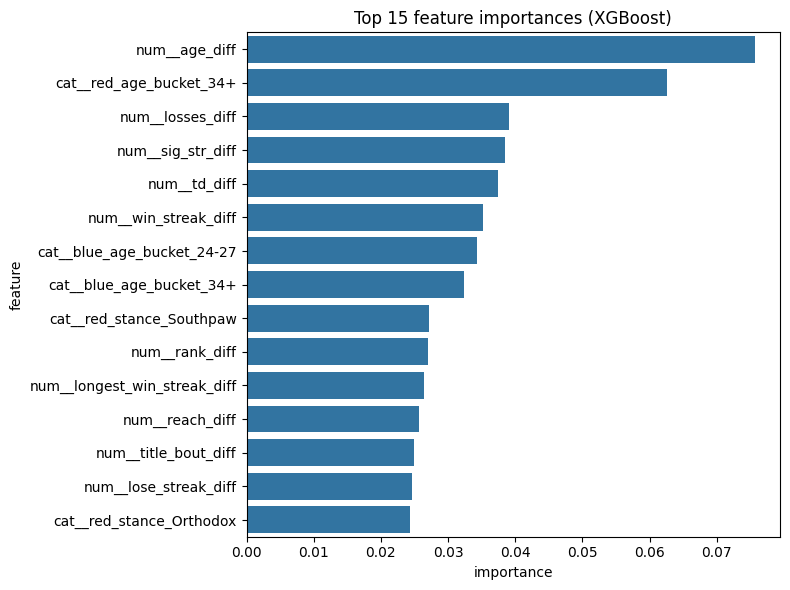

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_training_df["red_winner"])
y_test = le.transform(y_test_df["red_winner"])


categorical_features = ["red_stance", "blue_stance", "weight_class", "gender", "red_age_bucket", "blue_age_bucket"]
numeric_features = [
    "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff",
    "win_streak_diff", "longest_win_streak_diff", "lose_streak_diff",
    "title_bout_diff", "wins_diff", "rounds_diff", "height_diff",
    "ko_diff", "submission_diff"
]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

pipeline_xgb.fit(x_training_df, y_train)
y_predicted = pipeline_xgb.predict(x_test_df)

param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",   # accuracy alone is weak if red_winner is imbalanced — see note below
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(x_training_df, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search.best_score_)

best_index = grid_search.best_index_
print("Training score:", grid_search.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search.cv_results_["mean_test_score"][best_index])

print("================== Feature Importance ==================")
best_model = grid_search.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances (XGBoost)")
plt.tight_layout()
plt.show()

### MORE THINGS

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


x_train = x_training_df


# --- Feature groups ---
categorical_features = ["red_stance", "blue_stance", "weight_class", "gender",
                         "red_age_bucket", "blue_age_bucket"]
numeric_features = [
    "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff", "rounds_diff",
    "height_diff", "ko_diff", "submission_diff"
]

# --- Preprocessors ---
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# --- Pipelines ---
pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42))
])

pipeline_lr = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

pipeline_knn = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("clf", KNeighborsClassifier())
])

# --- Param grids ---
param_grid_xgb = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"]
}

param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features": ["sqrt", "log2"]
}

param_grid_knn = {
    "clf__n_neighbors": [5, 11, 21, 31],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}

# --- Grid searches ---
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5,
                                scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5,
                               scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5,
                               scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5,
                                scoring="roc_auc", n_jobs=-1, return_train_score=True)

grid_search_xgb.fit(x_train, y_train)
print("XGBoost done —", grid_search_xgb.best_params_, grid_search_xgb.best_score_)

grid_search_lr.fit(x_train, y_train)
print("Logistic Regression done —", grid_search_lr.best_params_, grid_search_lr.best_score_)

grid_search_rf.fit(x_train, y_train)
print("Random Forest done —", grid_search_rf.best_params_, grid_search_rf.best_score_)

grid_search_knn.fit(x_train, y_train)
print("kNN done —", grid_search_knn.best_params_, grid_search_knn.best_score_)

# --- Summary table ---
results_summary = pd.DataFrame({
    "model": ["XGBoost", "Logistic Regression", "Random Forest", "kNN"],
    "best_cv_roc_auc": [
        grid_search_xgb.best_score_,
        grid_search_lr.best_score_,
        grid_search_rf.best_score_,
        grid_search_knn.best_score_
    ]
}).sort_values("best_cv_roc_auc", ascending=False)

print()
print(results_summary)

XGBoost done — {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8} 0.6147488856122709


C:\Users\tumik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tumik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Logistic Regression done — {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'} 0.6228544545802496
Random Forest done — {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300} 0.6163616736881987
kNN done — {'clf__n_neighbors': 31, 'clf__p': 2, 'clf__weights': 'distance'} 0.5780621550719072

                 model  best_cv_roc_auc
1  Logistic Regression         0.622854
2        Random Forest         0.616362
0              XGBoost         0.614749
3                  kNN         0.578062


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# --- Feature groups ---
categorical_features = ["gender", "weight_class", "red_stance", "blue_stance",
                         "red_age_bucket", "blue_age_bucket"]
numeric_features = [
    "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff", "rounds_diff",
    "height_diff", "ko_diff", "submission_diff"
]

# --- Preprocessing: impute only — CatBoost handles cats and scale itself ---
preprocessor = ColumnTransformer([
    ("cat", SimpleImputer(strategy="constant", fill_value="missing"), categorical_features),
    ("num", SimpleImputer(strategy="median"), numeric_features)
], verbose_feature_names_out=False).set_output(transform="pandas")

# force categorical columns back to string after imputation (SimpleImputer can upcast dtypes)
def cast_cats_to_str(df):
    df = df.copy()
    df[categorical_features] = df[categorical_features].astype(str)
    return df

cast_step = FunctionTransformer(cast_cats_to_str)

# --- Pipeline (no cat_features in the constructor — passed via fit() instead) ---
pipeline_cb = Pipeline([
    ("preprocess", preprocessor),
    ("cast", cast_step),
    ("clf", CatBoostClassifier(
        random_seed=26,
        verbose=0
    ))
])

# --- Param grid ---
""" param_grid_cb = {
    "clf__iterations": [300, 500],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__depth": [4, 6, 8],
    "clf__l2_leaf_reg": [1, 3, 5]
} """

param_grid_cb = {
    "clf__iterations": [300, 500],
    "clf__learning_rate": [0.03, 0.05],
    "clf__depth": [4, 6],
    "clf__l2_leaf_reg": [1, 3]
}
# Hyper parameters for CatBoostClassifier


# --- Grid search ---
grid_search_cb = GridSearchCV(
    pipeline_cb, param_grid_cb,
    cv=5, scoring="roc_auc", n_jobs=-1, return_train_score=True
)


# cat_features passed here via clf__ prefix, forwarded to CatBoostClassifier.fit() on every fold
grid_search_cb.fit(x_train, y_train, clf__cat_features=categorical_features)

print("Best parameters:")
print(grid_search_cb.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_cb.best_score_)

best_index = grid_search_cb.best_index_
print("Training score:", grid_search_cb.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_cb.cv_results_["mean_test_score"][best_index])